# Chapter 15 Python Lab  
## Polar Coordinates and Change of Variables in the Plane

This lab accompanies **Chapter 15: Polar Coordinates and Change of Variables in the Plane**.

Many regions in the plane are easier to describe using coordinates adapted to their shape.  
Polar coordinates are the most important first example:

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

The key point is that the area element changes:

$$
dA=dx\,dy=r\,dr\,d\theta.
$$

More generally, for a transformation

$$
x=x(u,v),\qquad y=y(u,v),
$$

the area scaling factor is the absolute value of the Jacobian determinant:

$$
dA=\left|\frac{\partial(x,y)}{\partial(u,v)}\right|\,du\,dv.
$$

This lab uses Python to explore:

- the geometry of polar coordinates;
- why the polar area factor is $r$;
- double integrals over disks, annuli, and sectors;
- changing variables in double integrals;
- Jacobian determinants as local area scaling;
- linear transformations and determinant area factors;
- nonlinear transformations;
- probability and density transformations;
- Monte Carlo checks;
- and image-style coordinate warping.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. convert between Cartesian and polar coordinates;
2. visualize polar grids in the Cartesian plane;
3. compute polar area elements;
4. set up and approximate double integrals in polar coordinates;
5. recognize when polar coordinates simplify a region or integrand;
6. compute Jacobian matrices and determinants for coordinate changes;
7. interpret $|\det J|$ as a local area-scaling factor;
8. compare integration in original and transformed coordinates;
9. use linear and nonlinear changes of variables;
10. connect change of variables with probability densities and computational geometry.

## Source note

This notebook was generated from the uploaded Chapter 15 QMD file.  
The extracted early headings from the source file include:

- Learning objectives
- 15.1 Why change coordinates?
- 15.2 Polar coordinates
- Nonuniqueness of polar coordinates
- Practical convention
- 15.3 Common polar regions
- Disk centered at the origin
- Annulus centered at the origin
- Sector
- Upper half-disk
- Shifted circle
- Disk
- Annulus
- Sector

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def make_grid(xmin, xmax, ymin, ymax, n=300):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def cart_from_polar(r, theta):
    return r*np.cos(theta), r*np.sin(theta)

def polar_from_cart(x, y):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

def polar_grid(rmin, rmax, thetamin, thetamax, nr=200, nt=240):
    r = np.linspace(rmin, rmax, nr)
    theta = np.linspace(thetamin, thetamax, nt)
    R, T = np.meshgrid(r, theta)
    X = R*np.cos(T)
    Y = R*np.sin(T)
    return r, theta, R, T, X, Y

def polar_midpoint_integral(f_cart, rmin, rmax, thetamin, thetamax, nr=300, nt=360):
    dr = (rmax - rmin)/nr
    dt = (thetamax - thetamin)/nt
    r_mid = rmin + (np.arange(nr) + 0.5)*dr
    t_mid = thetamin + (np.arange(nt) + 0.5)*dt
    R, T = np.meshgrid(r_mid, t_mid)
    X, Y = cart_from_polar(R, T)
    Z = safe_eval_2d(f_cart, X, Y)
    return float(np.sum(Z*R)*dr*dt), R, T, X, Y, Z

def midpoint_rectangle_uv(integrand_uv, umin, umax, vmin, vmax, nu=300, nv=300):
    du = (umax - umin)/nu
    dv = (vmax - vmin)/nv
    u_mid = umin + (np.arange(nu) + 0.5)*du
    v_mid = vmin + (np.arange(nv) + 0.5)*dv
    U, V = np.meshgrid(u_mid, v_mid)
    W = safe_eval_2d(integrand_uv, U, V)
    return float(np.sum(W)*du*dv), U, V, W

def midpoint_region(f, xmin, xmax, ymin, ymax, mask, nx=500, ny=500):
    dx = (xmax - xmin)/nx
    dy = (ymax - ymin)/ny
    xmid = xmin + (np.arange(nx) + 0.5)*dx
    ymid = ymin + (np.arange(ny) + 0.5)*dy
    X, Y = np.meshgrid(xmid, ymid)
    inside = mask(X, Y)
    Z = safe_eval_2d(f, X, Y)
    return float(np.sum(Z[inside])*dx*dy), X, Y, Z, inside, dx, dy

def monte_carlo_region(f, xmin, xmax, ymin, ymax, mask, n=100_000, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(xmin, xmax, n)
    Y = rng.uniform(ymin, ymax, n)
    inside = mask(X, Y)
    values = np.zeros(n, dtype=float)
    values[inside] = safe_eval_2d(f, X[inside], Y[inside])
    box_area = (xmax - xmin)*(ymax - ymin)
    estimate = box_area*np.mean(values)
    standard_error = box_area*np.std(values, ddof=1)/np.sqrt(n)
    return float(estimate), float(standard_error), X, Y, inside, values

def finite_jacobian_2d(transform, u, v, h=1e-5):
    p = np.array([u, v], dtype=float)
    J = np.zeros((2, 2), dtype=float)
    for j in range(2):
        step = np.zeros(2)
        step[j] = h
        plus = np.array(transform(*(p + step)))
        minus = np.array(transform(*(p - step)))
        J[:, j] = (plus - minus)/(2*h)
    return J

def make_3d_axes(title=None, elev=30, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_mask(mask, xmin, xmax, ymin, ymax, title="Region", n=400):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    inside = mask(X, Y)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.contourf(X, Y, inside.astype(float), levels=[-0.5, 0.5, 1.5], alpha=0.45)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    plt.show()
    return X, Y, inside

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-5sz1jlvb because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Polar coordinates

Polar coordinates represent a point by distance from the origin and angle from the positive $x$-axis:

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

The inverse relations are

$$
r=\sqrt{x^2+y^2},\qquad \theta=\operatorname{atan2}(y,x).
$$

The same point can have many polar descriptions because angles repeat by multiples of $2\pi$.

## 1. Convert between Cartesian and polar coordinates

In [2]:
points = np.array([
    [1, 0],
    [0, 1],
    [-1, 0],
    [1, 1],
    [-2, 2],
    [3, -4]
], dtype=float)

print(f"{'x':>8s} {'y':>8s} {'r':>10s} {'theta':>12s} {'x back':>10s} {'y back':>10s}")
for x, y in points:
    r, theta = polar_from_cart(x, y)
    xb, yb = cart_from_polar(r, theta)
    print(f"{x:8.3f} {y:8.3f} {r:10.5f} {theta:12.5f} {xb:10.5f} {yb:10.5f}")

       x        y          r        theta     x back     y back
   1.000    0.000    1.00000      0.00000    1.00000    0.00000
   0.000    1.000    1.00000      1.57080    0.00000    1.00000
  -1.000    0.000    1.00000      3.14159   -1.00000    0.00000
   1.000    1.000    1.41421      0.78540    1.00000    1.00000
  -2.000    2.000    2.82843      2.35619   -2.00000    2.00000
   3.000   -4.000    5.00000     -0.92730    3.00000   -4.00000


## 2. Visualize a polar grid

The curves $r=\text{constant}$ become circles.  
The curves $\theta=\text{constant}$ become rays.

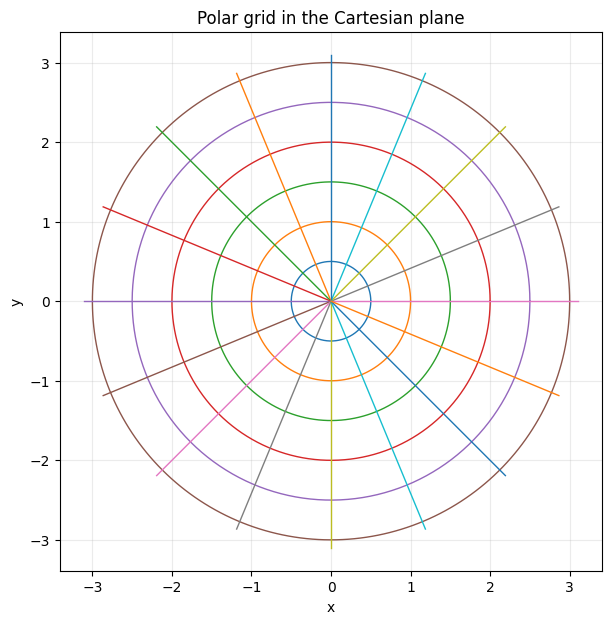

In [3]:
r_values = np.linspace(0.5, 3.0, 6)
theta_values = np.linspace(0, 2*np.pi, 16, endpoint=False)
theta_dense = np.linspace(0, 2*np.pi, 500)

plt.figure(figsize=(7, 7))

# Circles r = constant
for r0 in r_values:
    x = r0*np.cos(theta_dense)
    y = r0*np.sin(theta_dense)
    plt.plot(x, y, linewidth=1)

# Rays theta = constant
for t0 in theta_values:
    rr = np.linspace(0, 3.1, 200)
    x = rr*np.cos(t0)
    y = rr*np.sin(t0)
    plt.plot(x, y, linewidth=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polar grid in the Cartesian plane")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 3. Polar rectangles become curved sectors

A rectangle in the $(r,\theta)$-plane,

$$
a\le r\le b,\qquad \alpha\le \theta\le\beta,
$$

becomes an annular sector in the $xy$-plane.

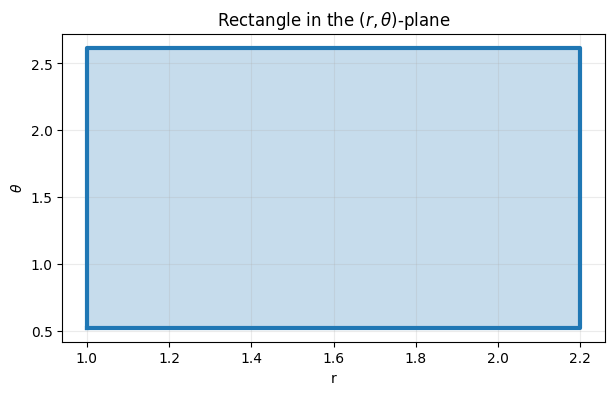

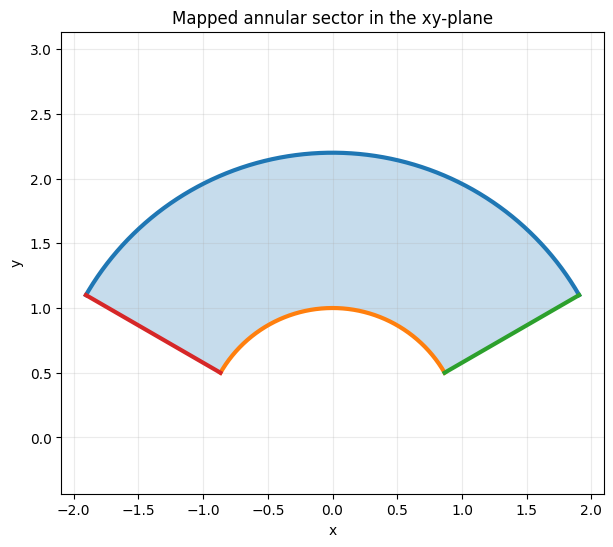

In [4]:
rmin, rmax = 1.0, 2.2
thetamin, thetamax = np.pi/6, 5*np.pi/6

# Draw in r-theta plane
fig, ax = plt.subplots(figsize=(7, 4))
rect_r = [rmin, rmax, rmax, rmin, rmin]
rect_t = [thetamin, thetamin, thetamax, thetamax, thetamin]
ax.plot(rect_r, rect_t, linewidth=3)
ax.fill(rect_r, rect_t, alpha=0.25)
ax.set_xlabel("r")
ax.set_ylabel(r"$\theta$")
ax.set_title(r"Rectangle in the $(r,\theta)$-plane")
ax.grid(True, alpha=0.25)
plt.show()

# Draw mapped region in xy-plane
theta = np.linspace(thetamin, thetamax, 300)
r_inner = rmin*np.ones_like(theta)
r_outer = rmax*np.ones_like(theta)
x_outer, y_outer = cart_from_polar(r_outer, theta)
x_inner, y_inner = cart_from_polar(r_inner, theta)

plt.figure(figsize=(7, 6))
plt.plot(x_outer, y_outer, linewidth=3)
plt.plot(x_inner, y_inner, linewidth=3)
plt.plot([rmin*np.cos(thetamin), rmax*np.cos(thetamin)],
         [rmin*np.sin(thetamin), rmax*np.sin(thetamin)], linewidth=3)
plt.plot([rmin*np.cos(thetamax), rmax*np.cos(thetamax)],
         [rmin*np.sin(thetamax), rmax*np.sin(thetamax)], linewidth=3)
plt.fill(np.r_[x_outer, x_inner[::-1]], np.r_[y_outer, y_inner[::-1]], alpha=0.25)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapped annular sector in the xy-plane")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part II. Why $dA=r\,dr\,d\theta$

The polar coordinate map is

$$
T(r,\theta)=(r\cos\theta,r\sin\theta).
$$

Its Jacobian matrix is

$$
J_T(r,\theta)=
\begin{bmatrix}
\cos\theta & -r\sin\theta\\
\sin\theta & r\cos\theta
\end{bmatrix}.
$$

The determinant is

$$
\det J_T=r.
$$

Therefore the area element is

$$
dA=r\,dr\,d\theta.
$$

## 4. Compute the polar Jacobian determinant

In [5]:
def polar_transform(r, theta):
    return r*np.cos(theta), r*np.sin(theta)

def polar_jacobian(r, theta):
    return np.array([
        [np.cos(theta), -r*np.sin(theta)],
        [np.sin(theta),  r*np.cos(theta)]
    ], dtype=float)

test_values = [
    (1.0, 0.0),
    (2.0, np.pi/6),
    (3.5, np.pi/3),
    (0.4, 2.2)
]

print(f"{'r':>8s} {'theta':>10s} {'det J':>12s} {'expected r':>12s} {'numeric det':>12s}")
for r0, t0 in test_values:
    J = polar_jacobian(r0, t0)
    det_exact = np.linalg.det(J)
    J_num = finite_jacobian_2d(polar_transform, r0, t0)
    det_num = np.linalg.det(J_num)
    print(f"{r0:8.3f} {t0:10.4f} {det_exact:12.6f} {r0:12.6f} {det_num:12.6f}")

       r      theta        det J   expected r  numeric det
   1.000     0.0000     1.000000     1.000000     1.000000
   2.000     0.5236     2.000000     2.000000     2.000000
   3.500     1.0472     3.500000     3.500000     3.500000
   0.400     2.2000     0.400000     0.400000     0.400000


## 5. Local area scaling experiment

Take a small rectangle in $(r,\theta)$-coordinates.  
Its area is approximately

$$
\Delta r\,\Delta\theta.
$$

After mapping to the plane, its area is approximately

$$
r\,\Delta r\,\Delta\theta.
$$

Input rectangle area in r-theta plane: 0.0048
Mapped quadrilateral area in xy-plane: 0.00959424103671136
Jacobian estimate r dr dtheta: 0.0096
Ratio mapped/input: 1.9988002159815335
Expected ratio r: 2.0


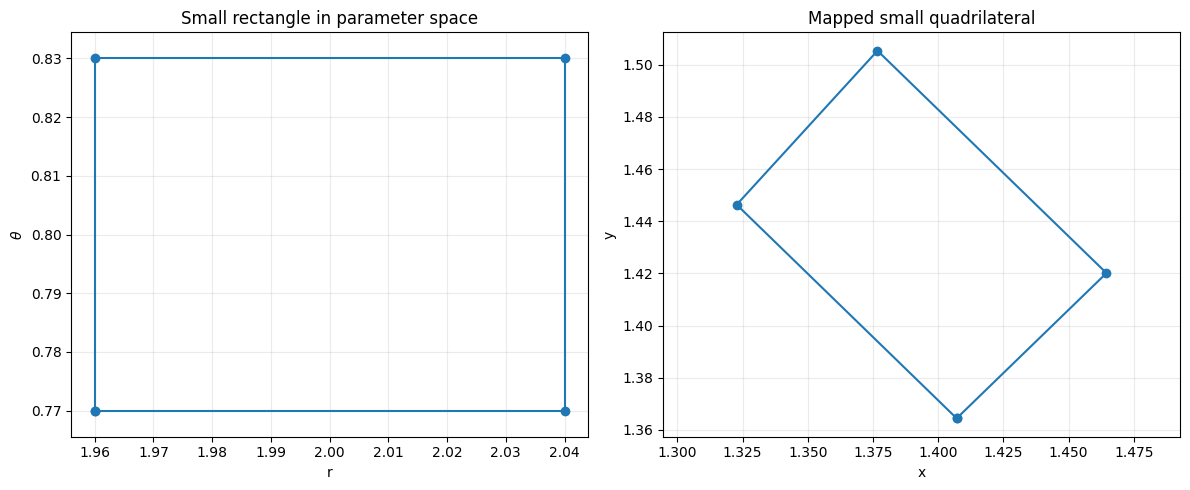

In [6]:
def polygon_area(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return 0.5*abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

r0, t0 = 2.0, 0.8
dr, dt = 0.08, 0.06

corners_rt = np.array([
    [r0-dr/2, t0-dt/2],
    [r0+dr/2, t0-dt/2],
    [r0+dr/2, t0+dt/2],
    [r0-dr/2, t0+dt/2],
    [r0-dr/2, t0-dt/2]
])

x_corners, y_corners = cart_from_polar(corners_rt[:,0], corners_rt[:,1])
input_area = dr*dt
mapped_area = polygon_area(x_corners[:-1], y_corners[:-1])
jacobian_estimate = r0*dr*dt

print("Input rectangle area in r-theta plane:", input_area)
print("Mapped quadrilateral area in xy-plane:", mapped_area)
print("Jacobian estimate r dr dtheta:", jacobian_estimate)
print("Ratio mapped/input:", mapped_area/input_area)
print("Expected ratio r:", r0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(corners_rt[:,0], corners_rt[:,1], marker="o")
axes[0].set_xlabel("r")
axes[0].set_ylabel(r"$\theta$")
axes[0].set_title("Small rectangle in parameter space")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].plot(x_corners, y_corners, marker="o")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Mapped small quadrilateral")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Key lesson

The factor $r$ appears because polar coordinate cells farther from the origin sweep out larger arc lengths.

---

# Part III. Double integrals in polar coordinates

If a region $D$ is described in polar coordinates by

$$
\alpha\le\theta\le\beta,\qquad a(\theta)\le r\le b(\theta),
$$

then

$$
\iint_D f(x,y)\,dA
=
\int_\alpha^\beta\int_{a(\theta)}^{b(\theta)}
f(r\cos\theta,r\sin\theta)\,r\,dr\,d\theta.
$$

## 6. Area of a disk

The unit disk is

$$
0\le r\le1,\qquad 0\le\theta\le2\pi.
$$

Thus

$$
\text{Area}=\int_0^{2\pi}\int_0^1 r\,dr\,d\theta=\pi.
$$

Polar midpoint disk area: 3.1415926535897936
Exact area: 3.141592653589793
Error: 4.440892098500626e-16


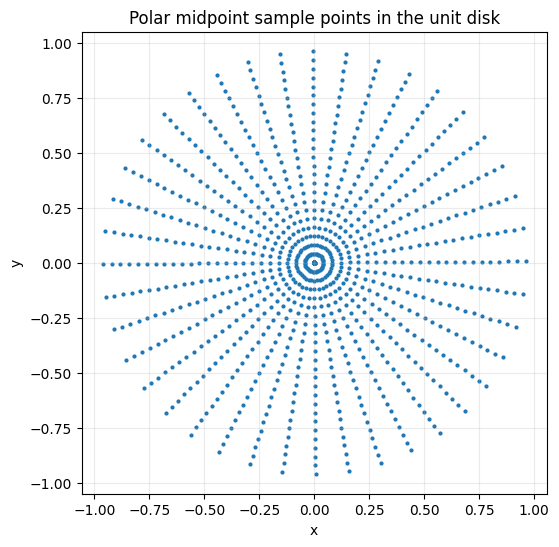

In [7]:
def one_cart(X, Y):
    return np.ones_like(np.asarray(X, dtype=float))

area_disk, R, T, X, Y, Z = polar_midpoint_integral(
    one_cart,
    0, 1,
    0, 2*np.pi,
    nr=300,
    nt=480
)

print("Polar midpoint disk area:", area_disk)
print("Exact area:", np.pi)
print("Error:", area_disk - np.pi)

plt.figure(figsize=(6, 6))
plt.scatter(X[::12, ::12], Y[::12, ::12], s=4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polar midpoint sample points in the unit disk")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 7. Integral of $x^2+y^2$ over a disk

Since

$$
x^2+y^2=r^2,
$$

we have

$$
\iint_{x^2+y^2\le a^2}(x^2+y^2)\,dA
=
\int_0^{2\pi}\int_0^a r^2\,r\,dr\,d\theta
=
\frac{\pi a^4}{2}.
$$

In [8]:
def r2_cart(X, Y):
    return X**2 + Y**2

a = 2.0
val_disk_r2, *_ = polar_midpoint_integral(
    r2_cart,
    0, a,
    0, 2*np.pi,
    nr=500,
    nt=720
)

exact = np.pi*a**4/2

print("Polar integral estimate:", val_disk_r2)
print("Exact value:", exact)
print("Error:", val_disk_r2 - exact)

Polar integral estimate: 25.13269096323589
Exact value: 25.132741228718345
Error: -5.02654824536819e-05


## 8. Annular sector

Let

$$
D=\{(r,\theta):1\le r\le3,\;\pi/6\le\theta\le 2\pi/3\}.
$$

Compute

$$
\iint_D (1+x^2+y^2)\,dA.
$$

In polar coordinates this becomes

$$
\int_{\pi/6}^{2\pi/3}\int_1^3(1+r^2)r\,dr\,d\theta.
$$

Integral estimate: 37.69907257316935
Exact value: 37.69911184307752
Error: -3.926990816438547e-05


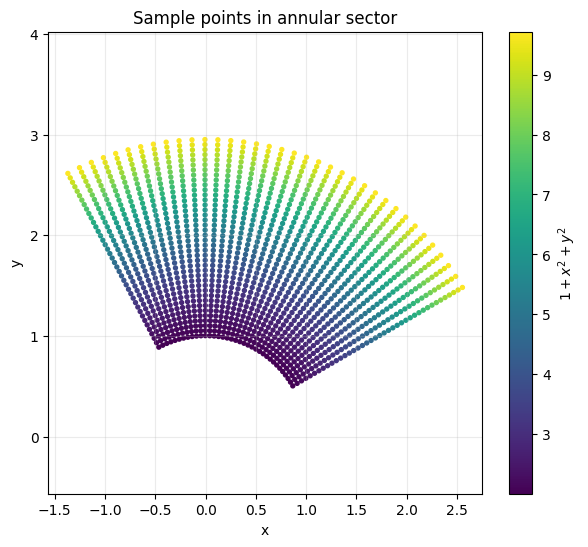

In [9]:
def f_annular(X, Y):
    return 1 + X**2 + Y**2

rmin, rmax = 1, 3
thetamin, thetamax = np.pi/6, 2*np.pi/3

val_annular, R, T, X, Y, Z = polar_midpoint_integral(
    f_annular,
    rmin, rmax,
    thetamin, thetamax,
    nr=400,
    nt=360
)

# Exact:
# (theta width) * ∫_1^3 (1+r^2)r dr = width * [r^2/2 + r^4/4]_1^3
width = thetamax - thetamin
exact_annular = width*((rmax**2-rmin**2)/2 + (rmax**4-rmin**4)/4)

print("Integral estimate:", val_annular)
print("Exact value:", exact_annular)
print("Error:", val_annular - exact_annular)

plt.figure(figsize=(7, 6))
plt.scatter(X[::10, ::10], Y[::10, ::10], c=Z[::10, ::10], s=8)
plt.colorbar(label=r"$1+x^2+y^2$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sample points in annular sector")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IV. Regions described by $r=g(\theta)$

Many curved regions are naturally described by a radial boundary

$$
0\le r\le g(\theta).
$$

Then

$$
\iint_D f(x,y)\,dA
=
\int_{\alpha}^{\beta}\int_0^{g(\theta)}
f(r\cos\theta,r\sin\theta)r\,dr\,d\theta.
$$

## 9. A cardioid-like region

Consider

$$
0\le r\le 1+\cos\theta,
\qquad
0\le\theta\le2\pi.
$$

We compute its area.

In [10]:
def polar_variable_upper_integral(f_cart, r_lower, r_upper, thetamin, thetamax, nt=720, nr=300):
    theta_mid = thetamin + (np.arange(nt) + 0.5)*(thetamax-thetamin)/nt
    dt = (thetamax-thetamin)/nt
    total = 0.0
    for th in theta_mid:
        a = r_lower(th)
        b = r_upper(th)
        dr = (b-a)/nr
        r_mid = a + (np.arange(nr) + 0.5)*dr
        x, y = cart_from_polar(r_mid, th)
        total += np.sum(safe_eval_2d(f_cart, x, y)*r_mid)*dr*dt
    return float(total)

r_upper_cardioid = lambda th: 1 + np.cos(th)

area_cardioid = polar_variable_upper_integral(
    one_cart,
    lambda th: 0,
    r_upper_cardioid,
    0, 2*np.pi,
    nt=1000,
    nr=200
)

# Exact: 1/2 ∫_0^{2π} (1+cos θ)^2 dθ = 3π/2
exact_cardioid_area = 3*np.pi/2

print("Cardioid area estimate:", area_cardioid)
print("Exact area:", exact_cardioid_area)
print("Error:", area_cardioid - exact_cardioid_area)

Cardioid area estimate: 4.712388980384692
Exact area: 4.71238898038469
Error: 2.6645352591003757e-15


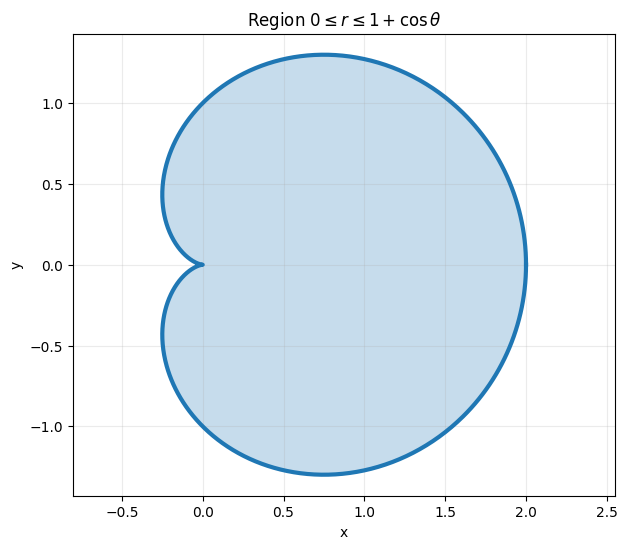

In [11]:
theta = np.linspace(0, 2*np.pi, 1000)
r = 1 + np.cos(theta)
x, y = cart_from_polar(r, theta)

plt.figure(figsize=(7, 6))
plt.plot(x, y, linewidth=3)
plt.fill(x, y, alpha=0.25)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Region $0\leq r\leq 1+\cos\theta$")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 10. Integral over the cardioid-like region

Compute

$$
\iint_D (x^2+y^2)\,dA.
$$

In polar coordinates the integrand is $r^2$ and $dA=r\,dr\,d\theta$, so the radial part contains $r^3$.

In [12]:
integral_cardioid_r2 = polar_variable_upper_integral(
    r2_cart,
    lambda th: 0,
    r_upper_cardioid,
    0, 2*np.pi,
    nt=1200,
    nr=300
)

# Exact: ∫∫ r^2 dA = ∫ 0.25*(1+cos θ)^4 dθ.
theta_dense = np.linspace(0, 2*np.pi, 20000)
exact_cardioid_r2 = np.trapezoid(0.25*(1+np.cos(theta_dense))**4, theta_dense)

print("Integral estimate:", integral_cardioid_r2)
print("High-resolution 1D reference:", exact_cardioid_r2)
print("Difference:", integral_cardioid_r2 - exact_cardioid_r2)

Integral estimate: 6.872195750650275
High-resolution 1D reference: 6.872233929727672
Difference: -3.8179077397337835e-05


### Guided task 1

Use polar coordinates to estimate the area inside

$$
r=2+\sin(3\theta),
\qquad
0\le\theta\le2\pi.
$$

Area estimate: 14.137166941154062
High-resolution reference: 14.13716694115407


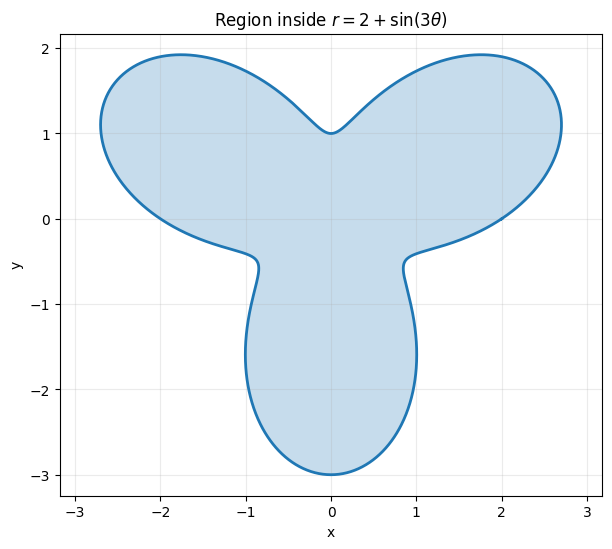

In [13]:
r_upper_task = lambda th: 2 + np.sin(3*th)

area_task = polar_variable_upper_integral(
    one_cart,
    lambda th: 0,
    r_upper_task,
    0, 2*np.pi,
    nt=1200,
    nr=100
)

theta_dense = np.linspace(0, 2*np.pi, 20000)
area_task_ref = np.trapezoid(0.5*(2+np.sin(3*theta_dense))**2, theta_dense)

print("Area estimate:", area_task)
print("High-resolution reference:", area_task_ref)

theta = np.linspace(0, 2*np.pi, 2000)
r = 2 + np.sin(3*theta)
x, y = cart_from_polar(r, theta)

plt.figure(figsize=(7, 6))
plt.plot(x, y, linewidth=2)
plt.fill(x, y, alpha=0.25)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Region inside $r=2+\sin(3\theta)$")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part V. Gaussian integrals and radial symmetry

Polar coordinates are especially useful when the integrand depends on

$$
x^2+y^2.
$$

For example,

$$
e^{-(x^2+y^2)}=e^{-r^2}.
$$

## 11. Gaussian integral over a disk

Compute

$$
\iint_{x^2+y^2\le R^2} e^{-(x^2+y^2)}\,dA.
$$

In polar coordinates:

$$
\int_0^{2\pi}\int_0^R e^{-r^2}r\,dr\,d\theta
=
\pi(1-e^{-R^2}).
$$

In [14]:
def gaussian_cart(X, Y):
    return np.exp(-(X**2 + Y**2))

for Rmax in [0.5, 1.0, 2.0, 3.0]:
    val, *_ = polar_midpoint_integral(
        gaussian_cart,
        0, Rmax,
        0, 2*np.pi,
        nr=500,
        nt=600
    )
    exact = np.pi*(1 - np.exp(-Rmax**2))
    print(f"R={Rmax:.1f}, estimate={val:.8f}, exact={exact:.8f}, error={val-exact:.2e}")

R=0.5, estimate=0.69491799, exact=0.69491783, error=1.60e-07


R=1.0, estimate=1.98586674, exact=1.98586530, error=1.43e-06
R=2.0, estimate=3.08405710, exact=3.08405238, error=4.73e-06


R=3.0, estimate=3.14121439, exact=3.14120495, error=9.44e-06


## 12. Why polar coordinates help

The Cartesian region $x^2+y^2\le R^2$ has curved boundaries.  
The polar version is the rectangle

$$
0\le r\le R,\qquad 0\le \theta\le2\pi.
$$

The radial symmetry is converted into a one-dimensional radial integral.

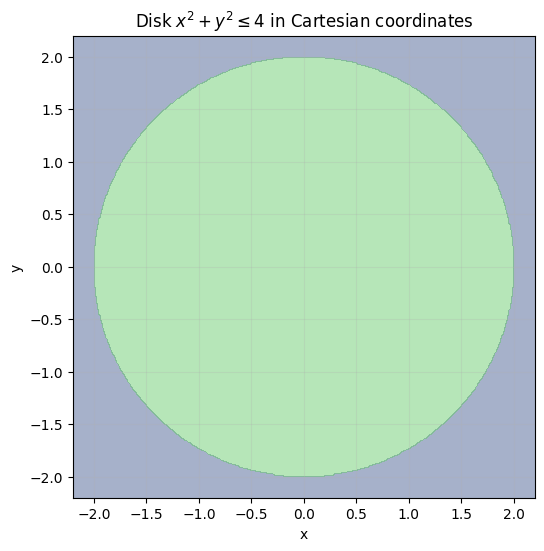

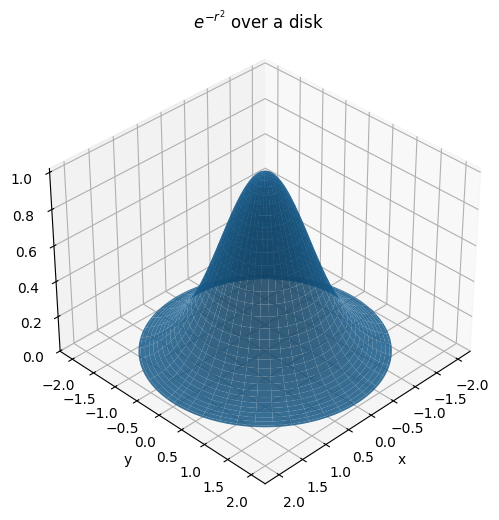

In [15]:
Rmax = 2.0
plot_mask(
    lambda X, Y: X**2 + Y**2 <= Rmax**2,
    -2.2, 2.2, -2.2, 2.2,
    title=r"Disk $x^2+y^2\leq 4$ in Cartesian coordinates"
)

r, theta, R, T, X, Y = polar_grid(0, Rmax, 0, 2*np.pi, nr=60, nt=90)
Z = gaussian_cart(X, Y)

fig, ax = make_3d_axes(title=r"$e^{-r^2}$ over a disk", elev=35, azim=45)
ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.85)
plt.show()

---

# Part VI. General change of variables

For a transformation

$$
T(u,v)=(x(u,v),y(u,v)),
$$

the change of variables formula is

$$
\iint_D f(x,y)\,dx\,dy
=
\iint_S f(x(u,v),y(u,v))
\left|\frac{\partial(x,y)}{\partial(u,v)}\right|\,du\,dv,
$$

where $T(S)=D$.

## 13. Linear transformations and determinant area scaling

Let

$$
\begin{bmatrix}x\\y\end{bmatrix}
=
A
\begin{bmatrix}u\\v\end{bmatrix},
\qquad
A=
\begin{bmatrix}
2 & 1\\
0.5 & 1.5
\end{bmatrix}.
$$

The area scaling factor is

$$
|\det A|.
$$

A =
[[2.  1. ]
 [0.5 1.5]]
det(A) = 2.5
area scaling factor |det(A)| = 2.5
Area of unit square: 1.0
Area after linear map: 2.5
Expected area: 2.5


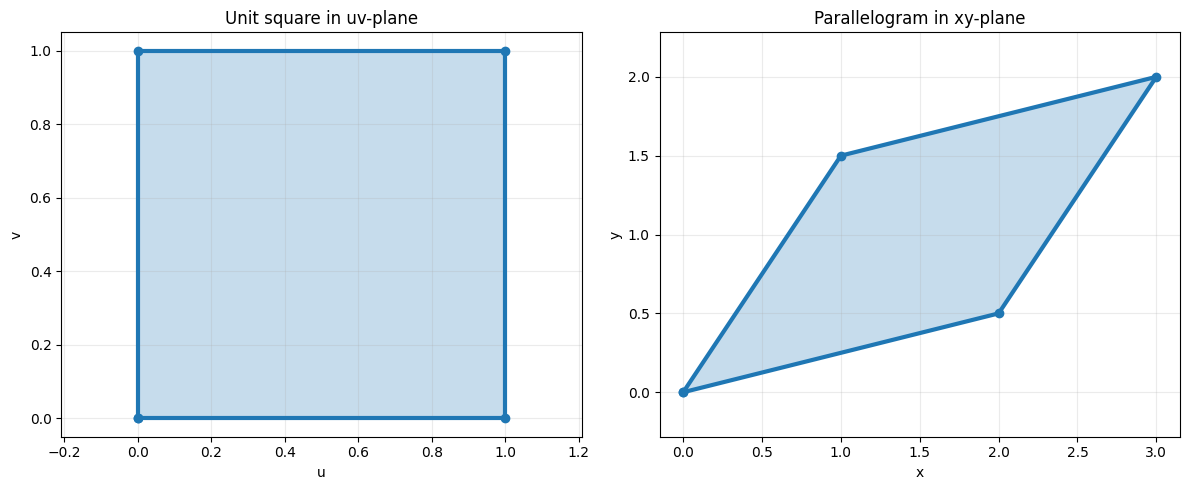

In [16]:
A = np.array([[2.0, 1.0],
              [0.5, 1.5]])

detA = np.linalg.det(A)

print("A =")
print(A)
print("det(A) =", detA)
print("area scaling factor |det(A)| =", abs(detA))

# Unit square in uv-plane
square_uv = np.array([
    [0,0],
    [1,0],
    [1,1],
    [0,1],
    [0,0]
], dtype=float)

square_xy = square_uv @ A.T

def polygon_area_points(P):
    return polygon_area(P[:,0], P[:,1])

area_uv = polygon_area_points(square_uv[:-1])
area_xy = polygon_area_points(square_xy[:-1])

print("Area of unit square:", area_uv)
print("Area after linear map:", area_xy)
print("Expected area:", abs(detA)*area_uv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(square_uv[:,0], square_uv[:,1], marker="o", linewidth=3)
axes[0].fill(square_uv[:,0], square_uv[:,1], alpha=0.25)
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
axes[0].set_title("Unit square in uv-plane")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].plot(square_xy[:,0], square_xy[:,1], marker="o", linewidth=3)
axes[1].fill(square_xy[:,0], square_xy[:,1], alpha=0.25)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Parallelogram in xy-plane")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 14. Integrate over a parallelogram by changing variables

Let $D$ be the parallelogram that is the image of the unit square under $A$.

Compute

$$
\iint_D (x+y)\,dA.
$$

Using the map $(x,y)=A(u,v)$,

$$
\iint_D (x+y)\,dA
=
\int_0^1\int_0^1
(x(u,v)+y(u,v))|\det A|\,du\,dv.
$$

In [17]:
def xy_from_uv_linear(U, V):
    X = A[0,0]*U + A[0,1]*V
    Y = A[1,0]*U + A[1,1]*V
    return X, Y

def integrand_linear_change(U, V):
    X, Y = xy_from_uv_linear(U, V)
    return (X + Y)*abs(detA)

val_linear_change, U, V, W = midpoint_rectangle_uv(
    integrand_linear_change,
    0, 1, 0, 1,
    nu=500,
    nv=500
)

# Analytic by expectation over unit square:
# X+Y = (2+0.5)u + (1+1.5)v = 2.5u + 2.5v
# integral over [0,1]^2 is 2.5
# multiply by det 2.5 gives 6.25.
exact_linear_change = abs(detA)*2.5

print("Change-of-variables estimate:", val_linear_change)
print("Exact value:", exact_linear_change)

Change-of-variables estimate: 6.25
Exact value: 6.25


## 15. Grid deformation under a linear map

A rectangular grid in $(u,v)$ maps to a parallelogram grid in $(x,y)$.

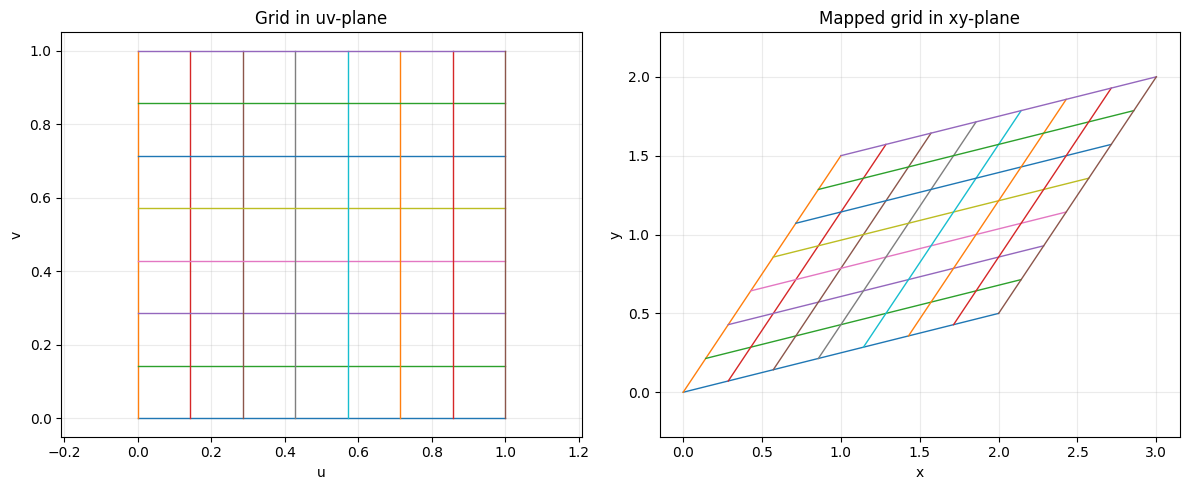

In [18]:
grid_lines = np.linspace(0, 1, 8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in grid_lines:
    u_line = np.linspace(0, 1, 100)
    v_line = c*np.ones_like(u_line)
    axes[0].plot(u_line, v_line, linewidth=1)
    axes[0].plot(v_line, u_line, linewidth=1)

    X1, Y1 = xy_from_uv_linear(u_line, v_line)
    X2, Y2 = xy_from_uv_linear(v_line, u_line)
    axes[1].plot(X1, Y1, linewidth=1)
    axes[1].plot(X2, Y2, linewidth=1)

axes[0].set_title("Grid in uv-plane")
axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].set_title("Mapped grid in xy-plane")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---

# Part VII. Nonlinear changes of variables

A nonlinear transformation can turn a simple rectangle in parameter space into a curved region.

The Jacobian determinant may vary from point to point.

## 16. A nonlinear transformation

Let

$$
x=u,\qquad y=uv.
$$

For

$$
1\le u\le2,\qquad 0\le v\le1,
$$

the image region is

$$
1\le x\le2,\qquad 0\le y\le x.
$$

The Jacobian matrix is

$$
J=
\begin{bmatrix}
1 & 0\\
v & u
\end{bmatrix},
$$

so

$$
|\det J|=u.
$$

In [19]:
def nonlinear_transform(u, v):
    return u, u*v

def nonlinear_jacobian_det(u, v):
    return u

def f_nonlinear_region(X, Y):
    return X + Y

def integrand_nonlinear(U, V):
    X, Y = nonlinear_transform(U, V)
    return f_nonlinear_region(X, Y)*abs(nonlinear_jacobian_det(U, V))

val_nonlinear, U, V, W = midpoint_rectangle_uv(
    integrand_nonlinear,
    1, 2, 0, 1,
    nu=700,
    nv=500
)

# Direct Type I region: 1 <= x <= 2, 0 <= y <= x.
def direct_integrand_region(X, Y):
    return X + Y

def direct_mask(X, Y):
    return (1 <= X) & (X <= 2) & (0 <= Y) & (Y <= X)

direct_val, *_ = midpoint_region(
    direct_integrand_region,
    1, 2, 0, 2,
    direct_mask,
    nx=800,
    ny=800
)

# Exact: ∫_1^2 ∫_0^x (x+y) dy dx
# inner = x^2 + x^2/2 = 3x^2/2, integral = (1/2)(8-1)=3.5
exact = 3.5

print("Change-of-variables estimate:", val_nonlinear)
print("Direct midpoint estimate:", direct_val)
print("Exact value:", exact)

Change-of-variables estimate: 3.4999997448979587
Direct midpoint estimate: 3.5000007812500002
Exact value: 3.5


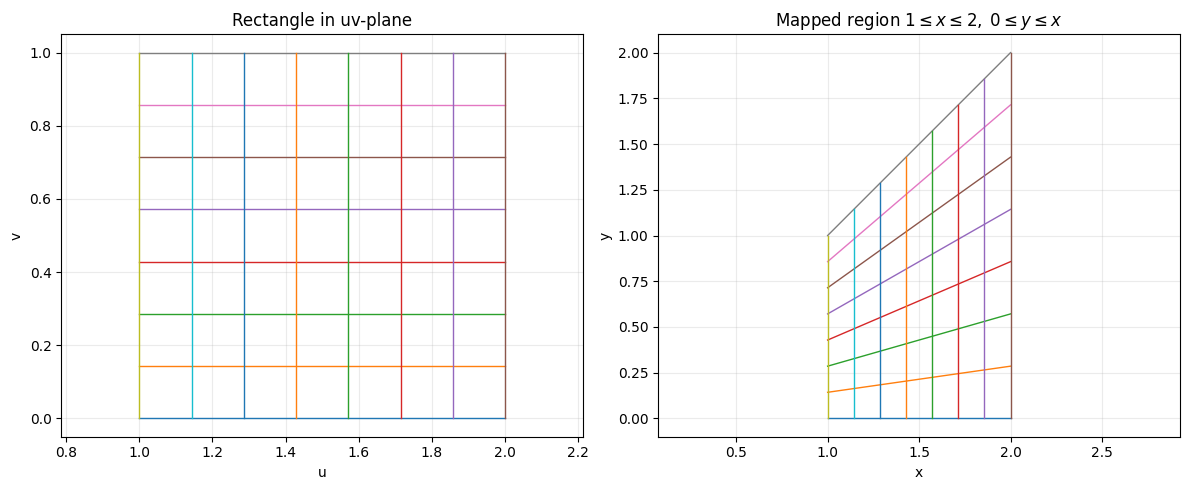

In [20]:
# Visualize parameter rectangle and mapped region.
u_lines = np.linspace(1, 2, 8)
v_lines = np.linspace(0, 1, 8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in v_lines:
    u_line = np.linspace(1, 2, 150)
    v_line = c*np.ones_like(u_line)
    axes[0].plot(u_line, v_line, linewidth=1)
    Xline, Yline = nonlinear_transform(u_line, v_line)
    axes[1].plot(Xline, Yline, linewidth=1)

for c in u_lines:
    v_line = np.linspace(0, 1, 150)
    u_line = c*np.ones_like(v_line)
    axes[0].plot(u_line, v_line, linewidth=1)
    Xline, Yline = nonlinear_transform(u_line, v_line)
    axes[1].plot(Xline, Yline, linewidth=1)

axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
axes[0].set_title("Rectangle in uv-plane")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title(r"Mapped region $1\leq x\leq2,\;0\leq y\leq x$")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 17. Numerical Jacobian check for the nonlinear map

In [21]:
test_points = [(1.2, 0.3), (1.8, 0.7), (2.0, 1.0)]

for u0, v0 in test_points:
    J_num = finite_jacobian_2d(nonlinear_transform, u0, v0)
    det_num = np.linalg.det(J_num)
    print("u,v =", (u0, v0))
    print("numeric Jacobian:")
    print(J_num)
    print("numeric det:", det_num)
    print("exact det:", nonlinear_jacobian_det(u0, v0))
    print()

u,v = (1.2, 0.3)
numeric Jacobian:
[[1.  0. ]
 [0.3 1.2]]
numeric det: 1.2000000000090616
exact det: 1.2

u,v = (1.8, 0.7)
numeric Jacobian:
[[1.  0. ]
 [0.7 1.8]]
numeric det: 1.8000000000080412
exact det: 1.8

u,v = (2.0, 1.0)
numeric Jacobian:
[[1. 0.]
 [1. 2.]]
numeric det: 2.0000000000151026
exact det: 2.0



---

# Part VIII. Change of variables for rotated and stretched regions

Linear transformations can simplify ellipses and rotated parallelograms.

For example, the ellipse

$$
\frac{x^2}{4}+\frac{y^2}{9}\le1
$$

is the image of the unit disk under

$$
x=2u,\qquad y=3v.
$$

The area scaling factor is $|\det A|=6$.

## 18. Ellipse from a disk

Compute the area of the ellipse

$$
\frac{x^2}{4}+\frac{y^2}{9}\le1.
$$

The exact area is

$$
\pi ab=6\pi.
$$

Grid estimate: 18.84945
Exact area: 18.84955592153876
Error: -0.00010592153875776944


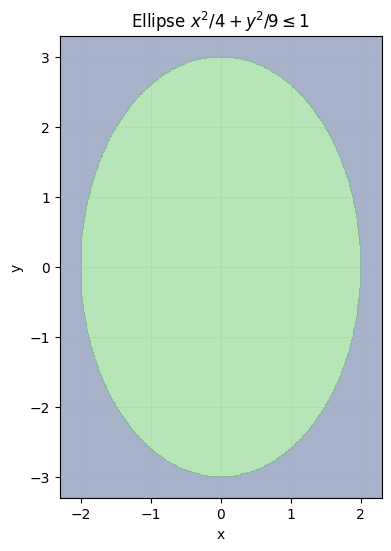

(array([[-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ],
        [-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ],
        [-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ],
        ...,
        [-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ],
        [-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ],
        [-2.3     , -2.288471, -2.276942, ...,  2.276942,  2.288471,
          2.3     ]], shape=(400, 400)),
 array([[-3.3     , -3.3     , -3.3     , ..., -3.3     , -3.3     ,
         -3.3     ],
        [-3.283459, -3.283459, -3.283459, ..., -3.283459, -3.283459,
         -3.283459],
        [-3.266917, -3.266917, -3.266917, ..., -3.266917, -3.266917,
         -3.266917],
        ...,
        [ 3.266917,  3.266917,  3.266917, ...,  3.266917,  3.266917,
          3.266917],
        [ 3.283459,  3.283459,  3.283459, ...,  3.2834

In [22]:
def ellipse_mask(X, Y):
    return X**2/4 + Y**2/9 <= 1

area_ellipse_grid, *_ = midpoint_region(
    one_cart,
    -2, 2, -3, 3,
    ellipse_mask,
    nx=800,
    ny=800
)

exact_ellipse_area = 6*np.pi

print("Grid estimate:", area_ellipse_grid)
print("Exact area:", exact_ellipse_area)
print("Error:", area_ellipse_grid - exact_ellipse_area)

plot_mask(
    ellipse_mask,
    -2.3, 2.3, -3.3, 3.3,
    title=r"Ellipse $x^2/4+y^2/9\leq1$"
)

## 19. Integral over an ellipse using disk coordinates

Let

$$
x=2r\cos\theta,\qquad y=3r\sin\theta,
$$

with

$$
0\le r\le1,\qquad 0\le\theta\le2\pi.
$$

The Jacobian factor is

$$
|J|=6r.
$$

Compute

$$
\iint_E (x^2+y^2)\,dA.
$$

In [23]:
def ellipse_polar_integral(f_cart, nr=500, nt=720):
    dr = 1/nr
    dt = 2*np.pi/nt
    r_mid = (np.arange(nr) + 0.5)*dr
    t_mid = (np.arange(nt) + 0.5)*dt
    R, T = np.meshgrid(r_mid, t_mid)
    X = 2*R*np.cos(T)
    Y = 3*R*np.sin(T)
    integrand = safe_eval_2d(f_cart, X, Y)*6*R
    return float(np.sum(integrand)*dr*dt)

ellipse_r2 = ellipse_polar_integral(r2_cart)

# Exact:
# ∫_0^{2π} ∫_0^1 [(4r^2 cos^2θ + 9r^2 sin^2θ)] 6r dr dθ
# radial ∫ r^3 dr=1/4; angular ∫(4cos^2+9sin^2)dθ = 13π
# exact = 6*(1/4)*13π = 39π/2
exact_ellipse_r2 = 39*np.pi/2

print("Ellipse integral estimate:", ellipse_r2)
print("Exact value:", exact_ellipse_r2)
print("Error:", ellipse_r2 - exact_ellipse_r2)

Ellipse integral estimate: 61.260934222887485
Exact value: 61.261056745000964
Error: -0.00012252211347885122


---

# Part IX. Probability density transformations

If $(U,V)$ has density $f_{U,V}(u,v)$ and

$$
(X,Y)=T(U,V),
$$

then densities transform using Jacobians.

For a one-to-one transformation,

$$
f_{X,Y}(x,y)
=
f_{U,V}(u,v)
\left|
\frac{\partial(u,v)}{\partial(x,y)}
\right|.
$$

Equivalently, probabilities are preserved:

$$
\iint_D f_{X,Y}(x,y)\,dx\,dy
=
\iint_{T^{-1}(D)} f_{U,V}(u,v)\,du\,dv.
$$

## 20. Uniform disk generated from polar coordinates

A common mistake is to sample

$$
R\sim \operatorname{Uniform}(0,1),\quad \Theta\sim \operatorname{Uniform}(0,2\pi)
$$

and set

$$
X=R\cos\Theta,\quad Y=R\sin\Theta.
$$

This does **not** produce uniform points in the disk because the polar area element is $r\,dr\,d\theta$.

For uniform area in the unit disk, use

$$
R=\sqrt{U},\qquad \Theta=2\pi V,
$$

where $U,V$ are uniform on $[0,1]$.

In [24]:
rng = np.random.default_rng(15)
n = 40_000

# Incorrect radial sampling
R_bad = rng.uniform(0, 1, n)
T_bad = rng.uniform(0, 2*np.pi, n)
X_bad, Y_bad = cart_from_polar(R_bad, T_bad)

# Correct radial sampling
U = rng.uniform(0, 1, n)
V = rng.uniform(0, 1, n)
R_good = np.sqrt(U)
T_good = 2*np.pi*V
X_good, Y_good = cart_from_polar(R_good, T_good)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_bad[:4000], Y_bad[:4000], s=3, alpha=0.5)
axes[0].set_title("Incorrect: R uniform")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X_good[:4000], Y_good[:4000], s=3, alpha=0.5)
axes[1].set_title(r"Correct: $R=\sqrt U$")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.25)

plt.show()

ValueError: 
R=\sqrt U
        ^
ParseSyntaxException: Expected \sqrt{value}, found 'U'  (at char 8), (line:1, col:9)

<Figure size 1200x500 with 2 Axes>

## 21. Radial distribution check

For uniform area in the unit disk,

$$
P(R\le r)=r^2.
$$

Thus the density of $R$ is

$$
f_R(r)=2r.
$$

In [25]:
r_bins = np.linspace(0, 1, 40)

plt.figure(figsize=(8, 4))
plt.hist(R_bad, bins=r_bins, density=True, alpha=0.6, label="incorrect R uniform")
plt.hist(R_good, bins=r_bins, density=True, alpha=0.6, label=r"correct $R=\sqrt U$")
r_line = np.linspace(0, 1, 300)
plt.plot(r_line, 2*r_line, linewidth=3, label=r"target density $2r$")
plt.xlabel("r")
plt.ylabel("density")
plt.title("Radial distribution in the unit disk")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

ValueError: 
R=\sqrt U
        ^
ParseSyntaxException: Expected \sqrt{value}, found 'U'  (at char 8), (line:1, col:9)

<Figure size 800x400 with 1 Axes>

---

# Part X. Monte Carlo checks for polar integrals

Monte Carlo sampling provides a useful check on polar integral calculations.

For a disk of radius $a$, the integral

$$
\iint_D f(x,y)\,dA
$$

can be estimated by sampling uniformly in a bounding box and keeping points in the disk.

## 22. Check the Gaussian disk integral with Monte Carlo

Compute

$$
\iint_{x^2+y^2\le4} e^{-(x^2+y^2)}\,dA.
$$

In [26]:
def disk_radius_2_mask(X, Y):
    return X**2 + Y**2 <= 4

polar_val, *_ = polar_midpoint_integral(
    gaussian_cart,
    0, 2,
    0, 2*np.pi,
    nr=600,
    nt=720
)

exact = np.pi*(1 - np.exp(-4))

print("Polar midpoint value:", polar_val)
print("Exact value:", exact)

for n in [5_000, 20_000, 100_000, 300_000]:
    mc_val, mc_se, *_ = monte_carlo_region(
        gaussian_cart,
        -2, 2, -2, 2,
        disk_radius_2_mask,
        n=n,
        seed=1500+n
    )
    print(f"n={n:8d}, MC estimate={mc_val:.8f}, SE={mc_se:.8f}, error={mc_val-exact:.8f}")

Polar midpoint value: 3.084055658844466
Exact value: 3.084052377011142
n=    5000, MC estimate=3.10195905, SE=0.05591330, error=0.01790667
n=   20000, MC estimate=3.08133527, SE=0.02785326, error=-0.00271711
n=  100000, MC estimate=3.07926134, SE=0.01251899, error=-0.00479104
n=  300000, MC estimate=3.08663599, SE=0.00721226, error=0.00258361


---

# Part XI. Image-style coordinate warping

Coordinate transformations are also used in graphics and image processing.

Here we visualize how a rectangular checkerboard in parameter space is warped by a nonlinear transformation.

## 23. A swirl-like transformation

Define

$$
x=u\cos(\alpha v),\qquad y=u\sin(\alpha v),
$$

where $u$ acts like a radius and $v$ acts like an angle-like coordinate.

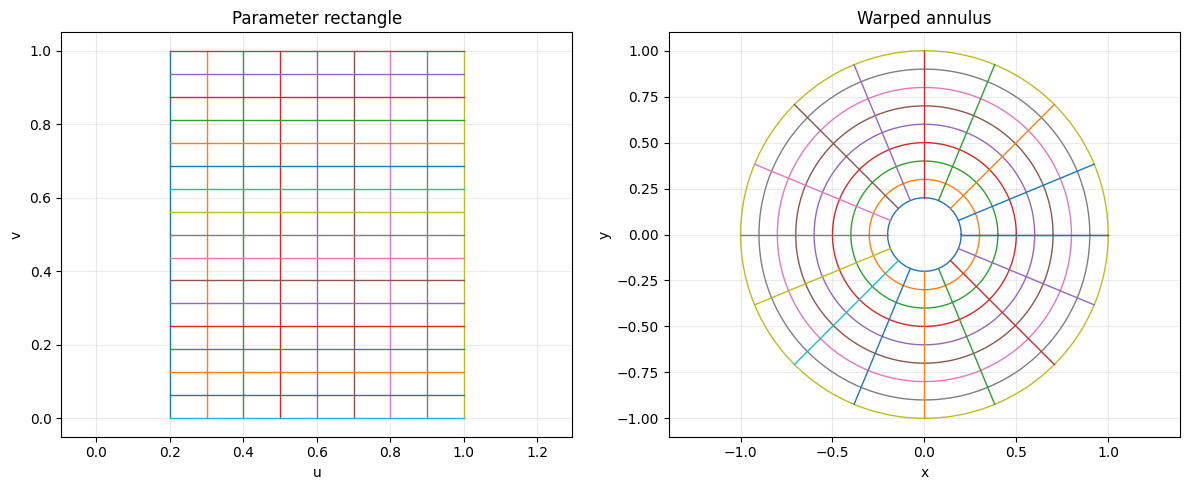

In [27]:
alpha = 2*np.pi

def swirl_transform(u, v):
    return u*np.cos(alpha*v), u*np.sin(alpha*v)

# Draw grid in parameter domain
u_lines = np.linspace(0.2, 1.0, 9)
v_lines = np.linspace(0.0, 1.0, 17)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in u_lines:
    vv = np.linspace(0, 1, 300)
    uu = c*np.ones_like(vv)
    axes[0].plot(uu, vv, linewidth=1)
    xw, yw = swirl_transform(uu, vv)
    axes[1].plot(xw, yw, linewidth=1)

for c in v_lines:
    uu = np.linspace(0.2, 1.0, 300)
    vv = c*np.ones_like(uu)
    axes[0].plot(uu, vv, linewidth=1)
    xw, yw = swirl_transform(uu, vv)
    axes[1].plot(xw, yw, linewidth=1)

axes[0].set_xlabel("u")
axes[0].set_ylabel("v")
axes[0].set_title("Parameter rectangle")
axes[0].axis("equal")
axes[0].grid(True, alpha=0.25)

axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Warped annulus")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

The transformation above is essentially polar coordinates with $\theta=2\pi v$.  
Its area factor is

$$
\left|\frac{\partial(x,y)}{\partial(u,v)}\right|=2\pi u.
$$

In [28]:
test_points = [(0.3, 0.1), (0.6, 0.4), (1.0, 0.8)]

for u0, v0 in test_points:
    J = finite_jacobian_2d(swirl_transform, u0, v0)
    print("u,v:", (u0, v0))
    print("Jacobian:")
    print(J)
    print("det:", np.linalg.det(J))
    print("expected absolute det:", 2*np.pi*u0)
    print()

u,v: (0.3, 0.1)
Jacobian:
[[ 0.809017 -1.107949]
 [ 0.587785  1.524961]]
det: 1.8849555909145113
expected absolute det: 1.8849555921538759

u,v: (0.6, 0.4)
Jacobian:
[[-0.809017 -2.215898]
 [ 0.587785 -3.049922]]
det: 3.7699111818046376
expected absolute det: 3.7699111843077517

u,v: (1.0, 0.8)
Jacobian:
[[ 0.309017  5.975664]
 [-0.951057  1.941611]]
det: 6.283185303023593
expected absolute det: 6.283185307179586



---

# Part XII. Chapter mini-project: design a change of variables

You will compute an integral over the ellipse

$$
E=\left\{(x,y):\frac{(x-1)^2}{4}+\frac{(y+2)^2}{9}\le1\right\}.
$$

Use the transformation

$$
x=1+2r\cos\theta,\qquad y=-2+3r\sin\theta,
$$

where

$$
0\le r\le1,\qquad 0\le\theta\le2\pi.
$$

The Jacobian factor is

$$
|J|=6r.
$$

Compute:

1. the area of $E$;
2. the integral of $f(x,y)=x^2+y^2$ over $E$;
3. the average value of $f$ over $E$;
4. a Monte Carlo check.

## 24. Ellipse transformation and integrals

In [29]:
def shifted_ellipse_transform(r, theta):
    x = 1 + 2*r*np.cos(theta)
    y = -2 + 3*r*np.sin(theta)
    return x, y

def shifted_ellipse_mask(X, Y):
    return ((X-1)**2)/4 + ((Y+2)**2)/9 <= 1

def shifted_ellipse_integral(f_cart, nr=600, nt=720):
    dr = 1/nr
    dt = 2*np.pi/nt
    r_mid = (np.arange(nr) + 0.5)*dr
    t_mid = (np.arange(nt) + 0.5)*dt
    R, T = np.meshgrid(r_mid, t_mid)
    X, Y = shifted_ellipse_transform(R, T)
    integrand = safe_eval_2d(f_cart, X, Y)*6*R
    return float(np.sum(integrand)*dr*dt), X, Y, integrand

area_E, Xs, Ys, area_integrand = shifted_ellipse_integral(one_cart)
integral_E, *_ = shifted_ellipse_integral(r2_cart)
avg_E = integral_E/area_E

print("Area of shifted ellipse:", area_E)
print("Exact area:", 6*np.pi)
print("Integral of x^2+y^2:", integral_E)
print("Average value:", avg_E)

Area of shifted ellipse: 18.84955592153876
Exact area: 18.84955592153876
Integral of x^2+y^2: 155.50875126789379
Average value: 8.249995486111114


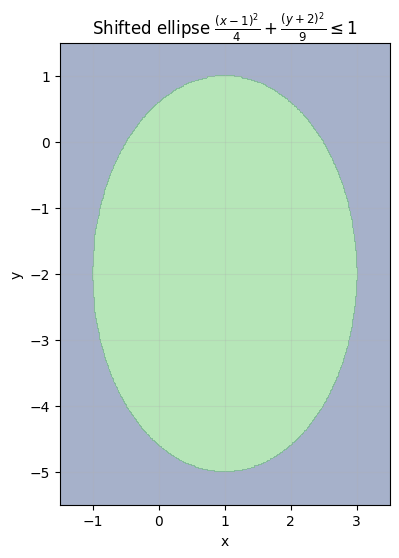

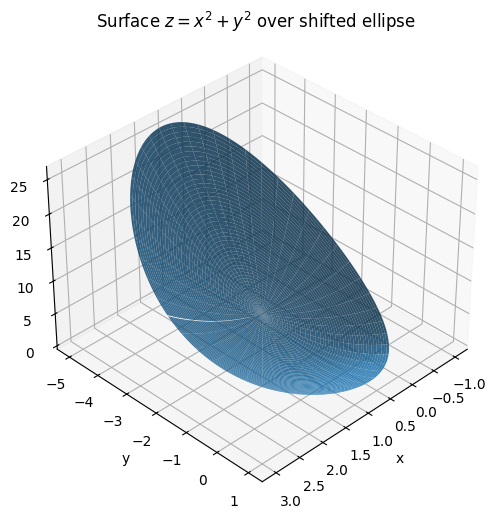

In [30]:
plot_mask(
    shifted_ellipse_mask,
    -1.5, 3.5, -5.5, 1.5,
    title=r"Shifted ellipse $\frac{(x-1)^2}{4}+\frac{(y+2)^2}{9}\leq1$"
)

fig, ax = make_3d_axes(title=r"Surface $z=x^2+y^2$ over shifted ellipse", elev=35, azim=45)
Z = r2_cart(Xs, Ys)
ax.plot_surface(Xs, Ys, Z, linewidth=0, alpha=0.85)
plt.show()

## 25. Monte Carlo check for the mini-project

In [31]:
grid_val, *_ = midpoint_region(
    r2_cart,
    -1.2, 3.2, -5.2, 1.2,
    shifted_ellipse_mask,
    nx=800,
    ny=800
)

print("Change-of-variables value:", integral_E)
print("Mask-grid value:", grid_val)
print("Difference:", integral_E - grid_val)

for n in [10_000, 50_000, 200_000, 500_000]:
    mc_val, mc_se, *_ = monte_carlo_region(
        r2_cart,
        -1.2, 3.2, -5.2, 1.2,
        shifted_ellipse_mask,
        n=n,
        seed=1515+n
    )
    print(f"n={n:8d}, MC estimate={mc_val:.6f}, SE={mc_se:.6f}, error vs CV={mc_val-integral_E:.6f}")

Change-of-variables value: 155.50875126789379
Mask-grid value: 155.52004227911803
Difference: -0.011291011224244585
n=   10000, MC estimate=157.708306, SE=1.897890, error vs CV=2.199555
n=   50000, MC estimate=156.754745, SE=0.846575, error vs CV=1.245994
n=  200000, MC estimate=155.428723, SE=0.421355, error vs CV=-0.080029
n=  500000, MC estimate=155.697310, SE=0.267105, error vs CV=0.188559


## 26. Mini-project questions

Answer the following in a markdown cell:

1. Why does the transformation turn the unit disk into the shifted ellipse?
2. Where does the Jacobian factor $6r$ come from?
3. Why is the average value equal to the integral divided by area?
4. Which method gave the most stable answer: change of variables, grid mask, or Monte Carlo?
5. How would the transformation change for an ellipse rotated by an angle?

In [32]:
print("Mini-project summary")
print("--------------------")
print("Area:", area_E)
print("Integral of x^2+y^2:", integral_E)
print("Average value:", avg_E)
print("Change-of-variables area error:", area_E - 6*np.pi)

Mini-project summary
--------------------
Area: 18.84955592153876
Integral of x^2+y^2: 155.50875126789379
Average value: 8.249995486111114
Change-of-variables area error: 0.0


---

# Part XIII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Polar area

Use polar coordinates to compute the area of the annulus

$$
1\le r\le4.
$$

In [33]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [34]:
area_A, *_ = polar_midpoint_integral(
    one_cart,
    1, 4,
    0, 2*np.pi,
    nr=500,
    nt=720
)
print("Numerical area:", area_A)
print("Exact area:", np.pi*(4**2 - 1**2))

Numerical area: 47.1238898038469
Exact area: 47.12388980384689


## Exercise B. Polar integral over a sector

Compute

$$
\iint_D (x^2+y^2)\,dA
$$

where

$$
D=\{(r,\theta):0\le r\le2,\;0\le\theta\le\pi/3\}.
$$

In [35]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [36]:
val_B, *_ = polar_midpoint_integral(
    r2_cart,
    0, 2,
    0, np.pi/3,
    nr=500,
    nt=360
)

# Exact: θ-width * ∫_0^2 r^3 dr = (π/3)*4 = 4π/3
print("Numerical value:", val_B)
print("Exact value:", 4*np.pi/3)

Numerical value: 4.188781827205982
Exact value: 4.1887902047863905


## Exercise C. Gaussian over disk

Compute

$$
\iint_{x^2+y^2\le9}e^{-(x^2+y^2)}\,dA.
$$

In [37]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [38]:
val_C, *_ = polar_midpoint_integral(
    gaussian_cart,
    0, 3,
    0, 2*np.pi,
    nr=700,
    nt=720
)
print("Numerical value:", val_C)
print("Exact value:", np.pi*(1-np.exp(-9)))

Numerical value: 3.141209768919594
Exact value: 3.1412049502558936


## Exercise D. Linear change of variables

Let

$$
x=3u+v,\qquad y=u+2v
$$

on the unit square $0\le u,v\le1$.

Compute the area of the image parallelogram and the integral of $f(x,y)=x-y$ over it.

In [39]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [40]:
B = np.array([[3.0, 1.0],
              [1.0, 2.0]])
detB = np.linalg.det(B)

def xy_from_uv_D(U, V):
    X = 3*U + V
    Y = U + 2*V
    return X, Y

def integrand_D(U, V):
    X, Y = xy_from_uv_D(U, V)
    return (X - Y)*abs(detB)

val_D, *_ = midpoint_rectangle_uv(integrand_D, 0, 1, 0, 1, nu=500, nv=500)
area_D = abs(detB)

print("Area of parallelogram:", area_D)
print("Integral of x-y:", val_D)

# Exact: x-y = 2u-v, integral over square = 1 - 1/2 = 1/2,
# multiply by det 5 gives 2.5.
print("Exact integral:", 2.5)

Area of parallelogram: 5.000000000000001
Integral of x-y: 2.5000000000000004
Exact integral: 2.5


## Exercise E. Uniform disk sampling

Generate uniform points in the disk of radius $3$ and estimate the average value of

$$
f(x,y)=x^2+y^2.
$$

The exact average value is

$$
\frac{R^2}{2}=\frac{9}{2}.
$$

In [41]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

Estimated average: 4.5008517585965935
Exact average: 4.5


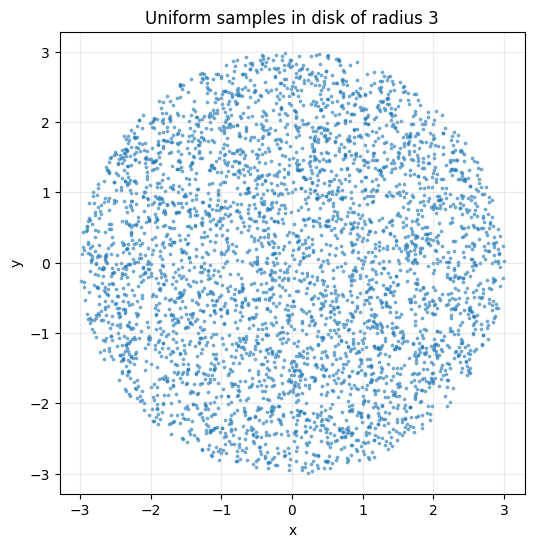

In [42]:
rng = np.random.default_rng(150)
n = 100_000
Rmax = 3.0

U = rng.uniform(0, 1, n)
V = rng.uniform(0, 1, n)
R = Rmax*np.sqrt(U)
Theta = 2*np.pi*V
X, Y = cart_from_polar(R, Theta)

avg = np.mean(X**2 + Y**2)
print("Estimated average:", avg)
print("Exact average:", Rmax**2/2)

plt.figure(figsize=(6, 6))
plt.scatter(X[:4000], Y[:4000], s=3, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Uniform samples in disk of radius 3")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Formula summary

## Polar coordinates

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

## Polar area element

$$
dA=r\,dr\,d\theta.
$$

## Polar double integral

$$
\iint_D f(x,y)\,dA
=
\int_\alpha^\beta\int_{a(\theta)}^{b(\theta)}
f(r\cos\theta,r\sin\theta)\,r\,dr\,d\theta.
$$

## Jacobian matrix

For

$$
x=x(u,v),\qquad y=y(u,v),
$$

the Jacobian matrix is

$$
J=
\begin{bmatrix}
x_u & x_v\\
y_u & y_v
\end{bmatrix}.
$$

## Change of variables

$$
\iint_D f(x,y)\,dx\,dy
=
\iint_S f(x(u,v),y(u,v))
\left|\det J(u,v)\right|\,du\,dv.
$$

## Linear transformation

If

$$
\begin{bmatrix}x\\y\end{bmatrix}
=A\begin{bmatrix}u\\v\end{bmatrix},
$$

then

$$
dA_{xy}=|\det A|\,dA_{uv}.
$$

## Ellipse from disk

For

$$
x=a r\cos\theta,\qquad y=b r\sin\theta,
$$

the area element is

$$
ab\,r\,dr\,d\theta.
$$

## Uniform disk sampling

For uniform area in a disk of radius $R$,

$$
r=R\sqrt U,\qquad \theta=2\pi V.
$$

# End of Chapter 15 Lab

You have used Python to explore:

- polar coordinates,
- polar grids and sectors,
- the Jacobian factor $r$,
- disk, annulus, sector, and cardioid integrals,
- radial symmetry and Gaussian integrals,
- general change of variables,
- linear and nonlinear transformations,
- ellipse transformations,
- probability density transformations,
- uniform disk sampling,
- Monte Carlo checks,
- and a shifted-ellipse mini-project.

These ideas prepare for triple integrals, cylindrical and spherical coordinates, vector fields, flux, probability transformations, and advanced integration methods.